# EDA для задачи ENTITY RESOLUTION

## 1. Основная информация о датасете

### Hackathon Dataset

Это набор для задачи по entity resolution в compliance-контексте.

#### Файл

- `student_relations.parquet` — основная таблица для работы
- `summary.json` — краткая статистика по итоговой выборке.

Одна строка в `student_relations.parquet` — это связь между компанией и связанным субъектом.

Примеры:
- компания и директор
- компания и владелец / участник
- компания и иное связанное лицо

#### Поля

- `record_id` — технический идентификатор строки
- `country` — страна источника
- `source_snapshot_date` — дата снапшота / дата фиксации записи
- `relation_kind` — общий тип связи, например `director` или `shareholder`
- `relation_role` — более конкретная роль из источника
- `party_type` — тип связанного субъекта, если он известен
- `company_public_id` — обезличенный идентификатор компании
- `company_name_norm` — нормализованное название компании
- `party_public_id` — обезличенный идентификатор субъекта, если он был доступен в источнике
- `party_name` — имя / наименование связанного субъекта в исходном источнике
- `ownership_share_pct` — доля владения, если она известна

#### Что можно решать

Основные задачи:
- дедупликация записей о людях и компаниях
- поиск совпадений для новой записи
- cross-country matching
- поиск случаев, где одна и та же сущность встречается в разных ролях и странах

Хорошие baseline-задачи:
- person-to-person matching по именам
- company-to-company matching по `company_name_norm`
- ranking top-K похожих записей
- clustering дублей

#### Что можно линковать с чем

Полезные типы сопоставления:
- `party_name` ↔ `party_name`
- `company_name_norm` ↔ `company_name_norm`
- `party_name` ↔ `company_name_norm`

Последний случай важен, потому что в части стран локальная компания может встретиться на стороне связанного субъекта, а не только как целевая компания в строке.

Дополнительные сигналы:
- `country`
- `relation_kind`
- `relation_role`
- `source_snapshot_date`
- `ownership_share_pct`

#### Ограничения и важные нюансы

- Реальные `tax_id` / `inn` / `voen` в студенческом датасете заменены на детерминированные surrogate key.
- `company_public_id` и `party_public_id` стабильны внутри выдачи, но не раскрывают исходный идентификатор.
- В текущую учебную выборку входят `arm`, `azb`, `kaz`, `kgz`, `mng`, `tjk`.
- `uzb` намеренно исключён из student-facing пакета, чтобы не раздувать объём и не ухудшать качество задач за счёт шумного exact matching.

#### Связь с брифом

Этот датасет подходит для следующих задач из брифа:
- дедупликация ФЛ и ЮЛ
- fuzzy matching
- мультиязычный matching
- cross-country matching
- построение search API и duplicate-check API
- кластеризация дублей
- оценка baseline и более сильных подходов

#### Размер набора

Итоговые строки по странам:

```
{
  "arm": 472261,
  "azb": 297747,
  "kaz": 796553,
  "kgz": 868689,
  "mng": 1210633,
  "tjk": 87364
}
```

## 2. Необходимые импорты

In [3]:
import pandas as pd
import numpy as np
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from rapidfuzz import fuzz
from rapidfuzz import process

import textdistance
from unidecode import unidecode

import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 3. Первичный осмотр данных

### 3.1 Загрузка и базовая информация

In [4]:
DATASET_PATH = "student_relations.parquet"

In [5]:
df = pd.read_parquet(DATASET_PATH)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3733247 entries, 0 to 3733246
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   record_id             str    
 1   country               str    
 2   source_snapshot_date  str    
 3   relation_kind         str    
 4   relation_role         str    
 5   party_type            str    
 6   company_public_id     str    
 7   company_name_norm     str    
 8   party_public_id       str    
 9   party_name            str    
 10  ownership_share_pct   float64
dtypes: float64(1), str(10)
memory usage: 1.0 GB


**Выводы:** Датасет содержит 3 733 247 записей в 11 колонках. Из типов даных нужно поправить колонку `source_snapshot_date` с str на datetime. Датасет занимает 1 Гб

### 3.2. Первывй взгляд на данные

Первые 5 записей

In [7]:
df.head()

,record_id,country,source_snapshot_date,relation_kind,relation_role,party_type,company_public_id,company_name_norm,party_public_id,party_name,ownership_share_pct
0,arm_rec_49df8429c4e1912e923f09210d5d2c39,arm,2023-01-09,shareholder,beneficial_owner,individual,arm_company_e8217b23afa28741,արոմատոս,NaN,Անդրանիկ Աբարյան,100.0
1,arm_rec_ee7466e19e5683c426051f8f94e13930,arm,2024-02-06,shareholder,beneficial_owner,individual,arm_company_997ee60051c4fda1,տրապիզոն քոնսթրաքշն,NaN,Տիգրան Հարությունյան,50.0
2,arm_rec_344e2597b9b2d65611c3ea6689aeb786,arm,2022-03-02,shareholder,beneficial_owner,individual,arm_company_ba593702ed7d5006,անհայտ կազմակերպություն,NaN,Նարեկ Նարգիզյան,30.0
3,arm_rec_bb45f92e3f36dcbedeb82569d875a6f9,arm,2024-01-18,shareholder,beneficial_owner,individual,arm_company_dbdf69c5afa462f3,լեոն ա յակուբյան քոնթրաքթինգ,NaN,ՎԱՍԿԵՆ ՅԱԿՈՒԲՅԱՆ,100.0
4,arm_rec_d4ffbf80b5b31e075113302d085b674f,arm,2024-01-30,shareholder,beneficial_owner,individual,arm_company_f39e74b9a9df4d74,սանտաֆամիլիա,NaN,Ժիրայր Ավանյան,15.0


Последние 5 записей

In [8]:
df.tail()

,record_id,country,source_snapshot_date,relation_kind,relation_role,party_type,company_public_id,company_name_norm,party_public_id,party_name,ownership_share_pct
3733242,tjk_rec_34dd101b5bef78a41ea372d4adff37ec,tjk,1546300800,director,director,individual,tjk_company_232d15ee9e46fd43,NaN,tjk_party_f556f4e0523cc391,Алиев А А,NaN
3733243,tjk_rec_85f86697b78d449c2ed67db6db492972,tjk,1546300800,director,director,individual,tjk_company_07ef7be724326416,NaN,tjk_party_890f935e3930016d,Солиева Малика Хусаиновна,NaN
3733244,tjk_rec_0b6a326feb0c71ab921abba41f16d12a,tjk,1546300800,director,director,individual,tjk_company_73c34b8b58d5e276,NaN,tjk_party_4e5b60c494368d47,Муминов Халил Саидович,NaN
3733245,tjk_rec_4c7989032abb43ca2f6cd90bff0e1b07,tjk,1546300800,director,director,individual,tjk_company_5afc3b60b8f09b5b,NaN,tjk_party_52c6a14aab10ec67,Почоев Олимджон Хабибуллоевич,NaN
3733246,tjk_rec_aa03f926843fd665c92be65d8a4707b1,tjk,1546300800,director,director,individual,tjk_company_8d42f23036cad7ba,NaN,tjk_party_4c4034a3c7e1ad7d,Файзуллоев Бахтиёр,NaN


Случайная выборка из 10 записей

In [9]:
df.sample(n=10, random_state=42)

,record_id,country,source_snapshot_date,relation_kind,relation_role,party_type,company_public_id,company_name_norm,party_public_id,party_name,ownership_share_pct
3034024,mng_rec_6e8abc36daedd005b5389e96ee7bcb0d,mng,2026-01-11,shareholder,shareholder,individual,mng_company_a7d988de7820698f,зэс эрдэнийн хувь,NaN,оюунчимэг уранчимэг,NaN
439061,arm_rec_987bea6e0a895dff3f0957861f16cc9c,arm,2024-02-15,shareholder,beneficial_owner,individual,arm_company_2af28ef7271c36f6,վմվ գրուպ,NaN,Վարդան Գալստյան,50.0
3639751,mng_rec_4956a6516f9525e6c5f9a2e07b33ebfd,mng,2026-01-11,ubo,ubo,individual,mng_company_5b765b60a4029aaa,гэгээн эрхэт хараа,NaN,Жамъяннаваг Эрдэнэбат,NaN
2116280,kgz_rec_bdcdb8c8379e471528b0eaa7dae52308,kgz,2022-02-15,shareholder,founder,unknown,kgz_company_a06a863f86b5008e,mohid international мохид интернэшнл жчк,NaN,Малик Наим Ахмед,NaN
1789927,kgz_rec_6ea98615f8d3782ae17fb7b74c022870,kgz,2022-02-15,shareholder,founder,unknown,kgz_company_92f04f93be0795c0,евро пласт euro plast жоопкерчилиги чектелген ...,NaN,Абаев Талгатбек Анварович,NaN
2591462,mng_rec_2d002799050c6742518b49d26711866f,mng,2026-01-11,director,Гүйцэтгэх захирал,individual,mng_company_ece1e814d2e194ae,түшилэгт хан групп,NaN,Өршөөлт Батбаяр,NaN
1402316,kaz_rec_b503378189583d29825fc8c1421da1dd,kaz,2025-12-04,director,director,individual,kaz_company_038b5bdd8f8755c7,сатыбалдиева перизат кыдырбеккызы,NaN,САТЫБАЛДИЕВА ПЕРИЗАТ КЫДЫРБЕККЫЗЫ,NaN
2798687,mng_rec_e7780254a258dd1967efc65607beebe9,mng,2026-01-11,shareholder,shareholder,individual,mng_company_c29ec1f96a27a190,дархан онон,NaN,очир лхамсүрэн,NaN
3313410,mng_rec_100a317621602f7fb1a7b3cab6a697b0,mng,2026-01-11,shareholder,shareholder,individual,mng_company_c4c693820bd0f2e2,зун мэн тианда эрчим уул уурхайн компани,NaN,Yang Shuxiang,NaN
745059,azb_rec_1a32edeb3a8eb26a8d7e0301f99afea6,azb,2013-02-06,director,director,individual,azb_company_ff01b849827c9658,NaN,NaN,TUMASOV SALMAN CƏFƏR OĞLU,NaN


**Выводы:** Необходимо обратить внимание на мультиязычность датасета и пропуски в данных.

### 3.3 Проверка целостности

In [10]:
df.isnull().sum()

record_id                     0
country                       0
source_snapshot_date          0
relation_kind                 0
relation_role                 0
party_type                    0
company_public_id         55136
company_name_norm        309960
party_public_id         3621106
party_name                    0
ownership_share_pct     3435090
dtype: int64

**Вывод:** Видим большое количество пропусков в некоторых полях, выполним более детальный анализ далее

## 4. Анализ пропусков и качества данных

### 4.1 Матрица пропусков

In [11]:
missing = pd.DataFrame({
    'Пропусков': df.isnull().sum(),
    'Процент': (df.isnull().sum() / len(df) * 100).round(2)
})

# Сортируем по убыванию
missing = missing.sort_values('Процент', ascending=False)

In [12]:

print(missing)

                      Пропусков  Процент
party_public_id         3621106    97.00
ownership_share_pct     3435090    92.01
company_name_norm        309960     8.30
company_public_id         55136     1.48
source_snapshot_date          0     0.00
record_id                     0     0.00
country                       0     0.00
party_type                    0     0.00
relation_role                 0     0.00
relation_kind                 0     0.00
party_name                    0     0.00


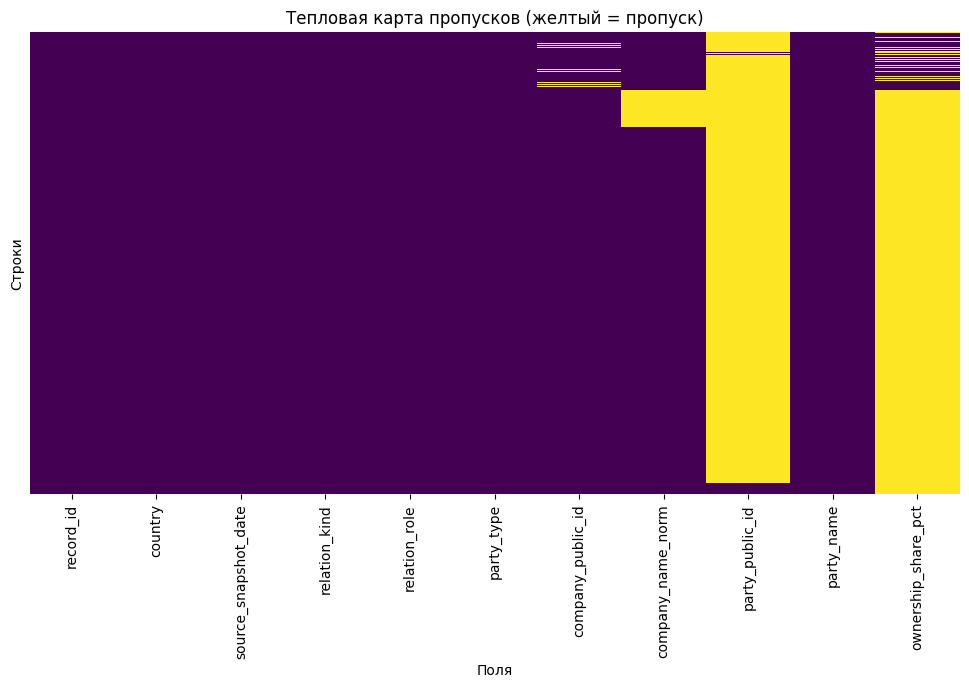

In [13]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Тепловая карта пропусков (желтый = пропуск)')
plt.xlabel('Поля')
plt.ylabel('Строки')
plt.show()

**Выводы:** 
1. `party_public_id`. Как видно неразмеченных данных 97 процентов от всего датасета. Размеченных данных для обучения достаточно
2. `ownership_share_pct`. Второстепенный признак, не обязательный для baseline
3. `company_name_norm`. Для связей `party_name` ↔ `company_name_norm` будет ограничение. Важное поле, но его отсутствие в 8% случаев нужно учитывать
4. `company_public_id`. Полезное поле, доступно в большинстве случаев


### 4.2 Категоризация записей

In [14]:
data = []
for has_id in [True, False]:
    subset = df[df['party_public_id'].notna() == has_id]
    label = 'Размеченные' if has_id else 'Неразмеченные'
    total = len(subset)
    
    all_three = (subset['company_name_norm'].notna() &  
                subset['ownership_share_pct'].notna() & 
                subset['company_public_id'].notna())
    
    data.append({
        'Тип данных': label,
        'Всего записей': total,
        'Есть company_name_norm': round(subset['company_name_norm'].notna().sum() / total * 100, 2),
        'Есть ownership_share_pct': round(subset['ownership_share_pct'].notna().sum() / total * 100, 2),
        'Есть company_public_id': round(subset['company_public_id'].notna().sum() / total * 100, 2)
    })

summary = pd.DataFrame(data)
summary = summary.set_index('Тип данных').T
print("Категоризация в процентах")
summary

Категоризация в процентах


Тип данных,Размеченные,Неразмеченные
Всего записей,112141.00,3621106.00
Есть company_name_norm,93.21,91.65
Есть ownership_share_pct,0.04,8.23
Есть company_public_id,99.15,98.50


**Вывод:** Структура размеченных и неразмеченных данных сопоставима. 

1. `company_public_id` — лучший контекстный признак. Заполнен на 99% в размеченных и на 98% в неразмеченных. Можно использовать для проверки: если две записи привязаны к одной компании, шанс дубликата выше.

2. `company_name_norm` — полезное дополнение. Заполнено на 93% в размеченных и на 91% в неразмеченных. Важно для связей "человек — компания".

3. `ownership_share_pct` — в размеченных данных практически отсутствует (0.04%). Для baseline-модели игнорируем.

## 5. Анализ категориальных признаков

### 5.1 Анализ распределния по странам

СТРАНА  КОЛИЧЕСТВО  ПРОЦЕНТ
mng      1,210,633    32.4%
kgz        868,689    23.3%
kaz        796,553    21.3%
arm        472,261    12.7%
azb        297,747     8.0%
tjk         87,364     2.3%


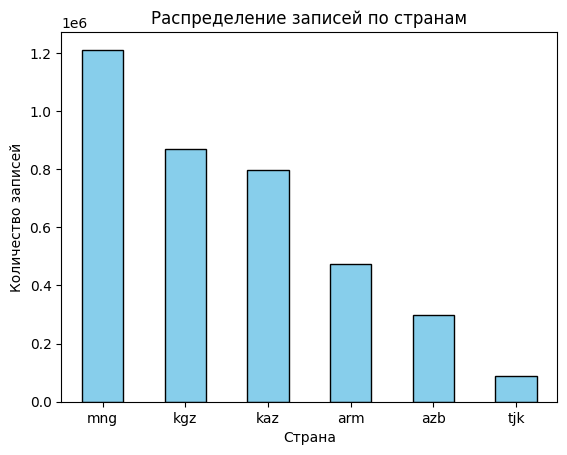


ДЕТАЛИ ПО СТРАНАМ:

mng:
  Период: 2026-01-11 — 2026-01-11
  Уникальных компаний: 269,067
  Уникальных имен: 763,858

kgz:
  Период: 2022-02-15 — 2026-01-03
  Уникальных компаний: 169,804
  Уникальных имен: 288,721

kaz:
  Период: 2024-10-04 — 2026-01-26
  Уникальных компаний: 700,794
  Уникальных имен: 632,722

arm:
  Период: 2021-02-18 — 2025-07-02
  Уникальных компаний: 5,060
  Уникальных имен: 5,643

azb:
  Период: 2006-07-28 — 2026-03-30
  Уникальных компаний: 0
  Уникальных имен: 188,846

tjk:
  Период: 1298937600 — 1664323200
  Уникальных компаний: 38,243
  Уникальных имен: 53,077


In [15]:
# Распределение по странам (количество и %)
country_counts = df['country'].value_counts()
country_pct = (df['country'].value_counts(normalize=True) * 100).round(1)

print("СТРАНА  КОЛИЧЕСТВО  ПРОЦЕНТ")
for c in country_counts.index:
    print(f"{c:<7} {country_counts[c]:>10,}  {country_pct[c]:>6.1f}%")

# График
country_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Распределение записей по странам')
plt.xlabel('Страна')
plt.ylabel('Количество записей')
plt.xticks(rotation=0)
plt.show()

# Детали по каждой стране
print("\nДЕТАЛИ ПО СТРАНАМ:")
for c in country_counts.index:
    subset = df[df['country'] == c]
    print(f"\n{c}:")
    print(f"  Период: {subset['source_snapshot_date'].min()} — {subset['source_snapshot_date'].max()}")
    print(f"  Уникальных компаний: {subset['company_name_norm'].nunique():,}")
    print(f"  Уникальных имен: {subset['party_name'].nunique():,}")

**Выводы:** В выводах посмотрим на аномалии:
1. Монголия (mng): Все записи за одну дату (2026-01-11) — возможно снапшот. 533 тыс. уникальных имен — больше всех

2. Армения (arm): Всего 5,060 компаний и 5,643 имен — очень мало уникальных сущностей. Много дубликатов

3. Азербайджан (azb): 0 уникальных компаний — вообще нет названий компаний. Есть только имена (188,846)

4. Таджикистан (tjk): Даты в Unix timestamp — нужно преобразовать. Самый маленький сегмент (2.3%)

### 5.2 Анализ типов связей

In [16]:
print("ЧАСТОТА relation_kind:")
print(df['relation_kind'].value_counts())
print(f"\nУникальных значений: {df['relation_kind'].nunique()}")

print("\nРАСПРЕДЕЛЕНИЕ ПО СТРАНАМ:")
cross = pd.crosstab(df['country'], df['relation_kind'])
print(cross)

print("\nВ ПРОЦЕНТАХ ПО СТРАНЕ:")
cross_pct = pd.crosstab(df['country'], df['relation_kind'], normalize='index') * 100
print(cross_pct.round(1))

ЧАСТОТА relation_kind:
relation_kind
shareholder    1809749
director       1595567
ubo             327931
Name: count, dtype: int64

Уникальных значений: 3

РАСПРЕДЕЛЕНИЕ ПО СТРАНАМ:
relation_kind  director  shareholder     ubo
country                                     
arm                   0       472261       0
azb              297747            0       0
kaz              796553            0       0
kgz              199233       669456       0
mng              247093       635609  327931
tjk               54941        32423       0

В ПРОЦЕНТАХ ПО СТРАНЕ:
relation_kind  director  shareholder   ubo
country                                   
arm                 0.0        100.0   0.0
azb               100.0          0.0   0.0
kaz               100.0          0.0   0.0
kgz                22.9         77.1   0.0
mng                20.4         52.5  27.1
tjk                62.9         37.1   0.0


Выводы: 
- arm, azb, kaz — только один тип связи (бесполезен как признак)

- kgz, mng, tjk — есть микс, можно использовать как слабый признак

- ubo встречается только в Монголии — для других стран не применим

`relation_kind` можно использовать как контекст, но не как ключевой признак для матчинга

### 5.3 Анализ более конкретных ролей

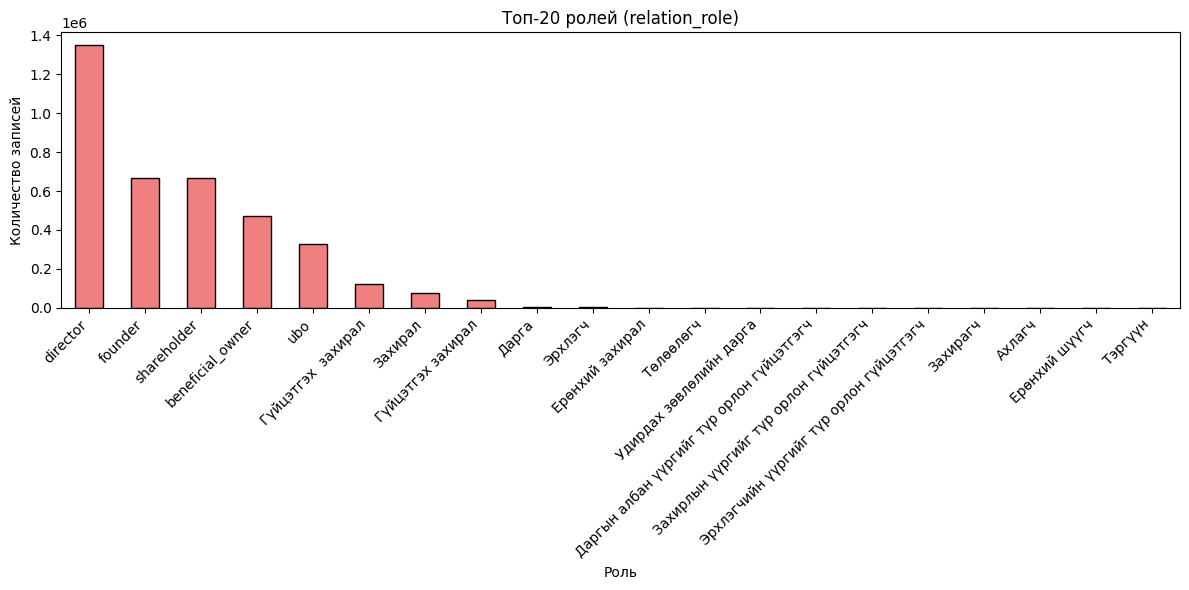


ТОП-5 РОЛЕЙ ПО СТРАНАМ:

arm:
relation_role
beneficial_owner    472261
Name: count, dtype: int64

azb:
relation_role
director    297747
Name: count, dtype: int64

kaz:
relation_role
director    796553
Name: count, dtype: int64

kgz:
relation_role
founder     669456
director    199233
Name: count, dtype: int64

mng:
relation_role
shareholder           635609
ubo                   327931
Гүйцэтгэх  захирал    121198
Захирал                73927
Гүйцэтгэх захирал      40573
Name: count, dtype: int64

tjk:
relation_role
director       54941
shareholder    32423
Name: count, dtype: int64


In [17]:
# Топ-20 ролей — столбчатая диаграмма
top_roles = df['relation_role'].value_counts().head(20)

plt.figure(figsize=(12, 6))
top_roles.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Топ-20 ролей (relation_role)')
plt.xlabel('Роль')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# По странам
print("\nТОП-5 РОЛЕЙ ПО СТРАНАМ:")
for c in df['country'].unique():
    print(f"\n{c}:")
    print(df[df['country']==c]['relation_role'].value_counts().head(5))

**Вывод:** mng — единственная страна с разнообразием ролей, включая роли на монгольском языке. `relation_role` не ключевой признак для baseline

### 5.4 Анализ типов субъектов

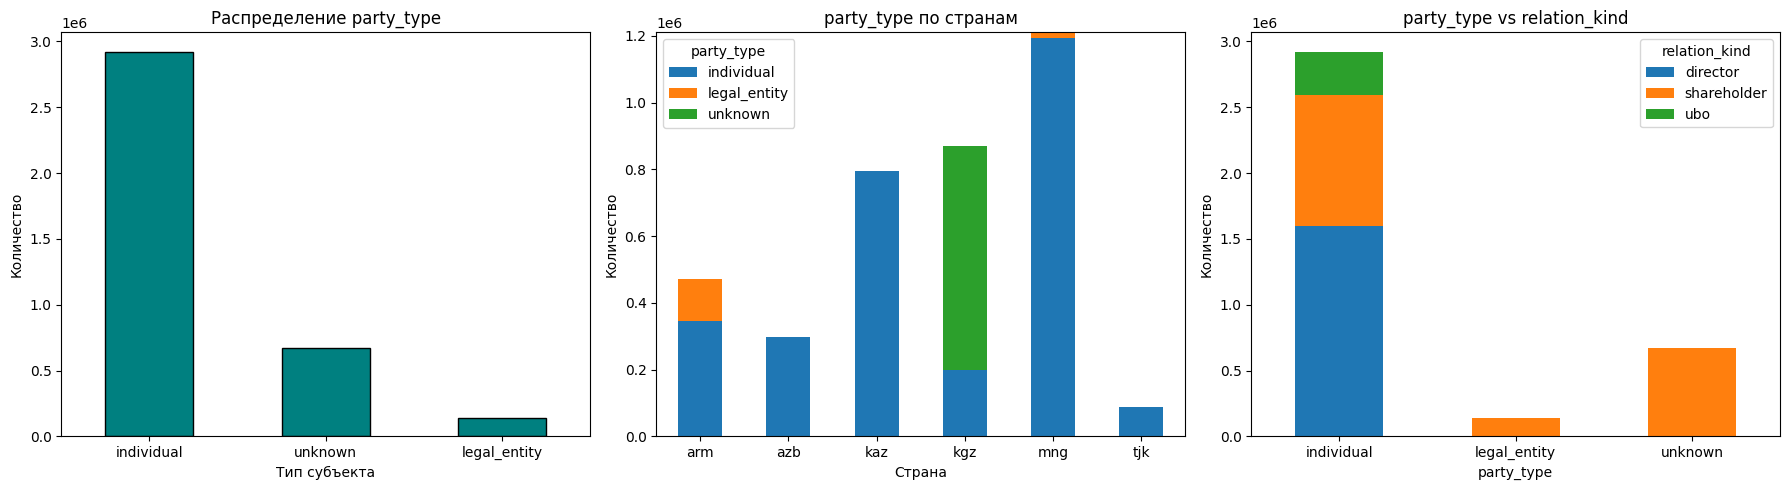

In [18]:
# Создаем subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Распределение party_type
df['party_type'].value_counts().plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Распределение party_type')
axes[0].set_xlabel('Тип субъекта')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

# 2. По странам
pd.crosstab(df['country'], df['party_type']).plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('party_type по странам')
axes[1].set_xlabel('Страна')
axes[1].set_ylabel('Количество')
axes[1].legend(title='party_type')
axes[1].tick_params(axis='x', rotation=0)

# 3. Связь с relation_kind
pd.crosstab(df['party_type'], df['relation_kind']).plot(kind='bar', stacked=True, ax=axes[2])
axes[2].set_title('party_type vs relation_kind')
axes[2].set_xlabel('party_type')
axes[2].set_ylabel('Количество')
axes[2].legend(title='relation_kind')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Вывод**: `party_type` полезен для различения ФЛ и ЮЛ. Если `party_type` = legal_entity → 100% shareholder. Если `party_type` = individual → любая роль. Можно использовать как слабый признак

### 5.5 Общий вывод:

**Что полезно для модели:**

`country` — важный признак. Правила транслитерации и алфавиты зависят от страны.

`party_type` — полезен. Разделяет ФЛ и ЮЛ. legal_entity всегда shareholder.

`company_public_id` — самый сильный контекстный признак. Заполнен на 99% в разметке.

**Что бесполезно для baseline:**

`relation_kind` — для arm, azb, kaz только один тип связи. Слабый признак.

`relation_role` — для большинства стран одна роль. Только в mng есть разнообразие.

`ownership_share_pct` — в размеченных данных почти отсутствует (0.04%).

**Итого:**

- Сильные признаки: party_name + country + company_public_id + party_type
- Слабые признаки: relation_kind, relation_role
- Игнорируем: ownership_share_pct, record_id

## 6. Анализ текстовых данных

### 6.1 Анализ имен

Уникальных имен: 1,932,720
Средняя длина: 22.6
Мин длина: 1
Макс длина: 296


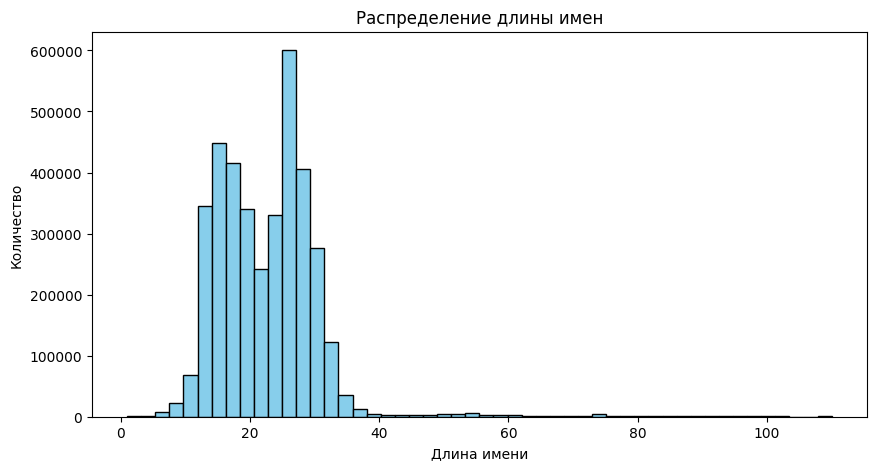


ТОП-10 ИМЕН:
party_name
Անհայտ կազմակերպություն                                                      50737
ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ                                                   14496
Միրզաազիզ Մուսախանով                                                         11003
Սվետլանա Երշովա                                                               8870
ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ                                               8172
ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ                                                        5316
ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ բաժնետոմսերով սահմանափակ մասնավոր ընկերություն     3675
Замените на физическое лицо 1                                                 3225
Замените на физическое лицо 2                                                 3151
Замените на физическое лицо 3                                                 2927
Name: count, dtype: int64

КОРОТКИЕ ИМЕНА (1-2 символа):
party_name
-     14
Ли    14
Ив    12
Су     6
Лу     6
Ма     6
Ян     5
ГП     5
Лю   

In [19]:
name_len = df['party_name'].dropna().str.len()

# Количество уникальных
print(f"Уникальных имен: {df['party_name'].nunique():,}")
print(f"Средняя длина: {name_len.mean():.1f}")
print(f"Мин длина: {name_len.min()}")
print(f"Макс длина: {name_len.max()}")

# Гистограмма
plt.figure(figsize=(10, 5))
plt.hist(name_len.clip(0, 110), bins=50, edgecolor='black', color='skyblue')
plt.title('Распределение длины имен')
plt.xlabel('Длина имени')
plt.ylabel('Количество')
plt.show()

# Топ-10 имен
print("\nТОП-10 ИМЕН:")
print(df['party_name'].value_counts().head(10))

# Аномально короткие (1-2 символа)
short = df[df['party_name'].str.len() <= 2]['party_name'].value_counts().head(10)
print("\nКОРОТКИЕ ИМЕНА (1-2 символа):")
print(short)

# Аномально длинные (100+симоволов)
long = df[df['party_name'].str.len() >= 100]['party_name'].value_counts().head(5)
print("\nДЛИННЫЕ ИМЕНА (100+ символов):")
print(long)

**Вывод:** Из интересного можно выделить сокращения. Не ясно что они значат. Для модели потребуется нормализация к нижнему регистру ну и транслитерация. С короткими именами пока не ясно что делать.

### 6.2 Анализ алфавитов и языков

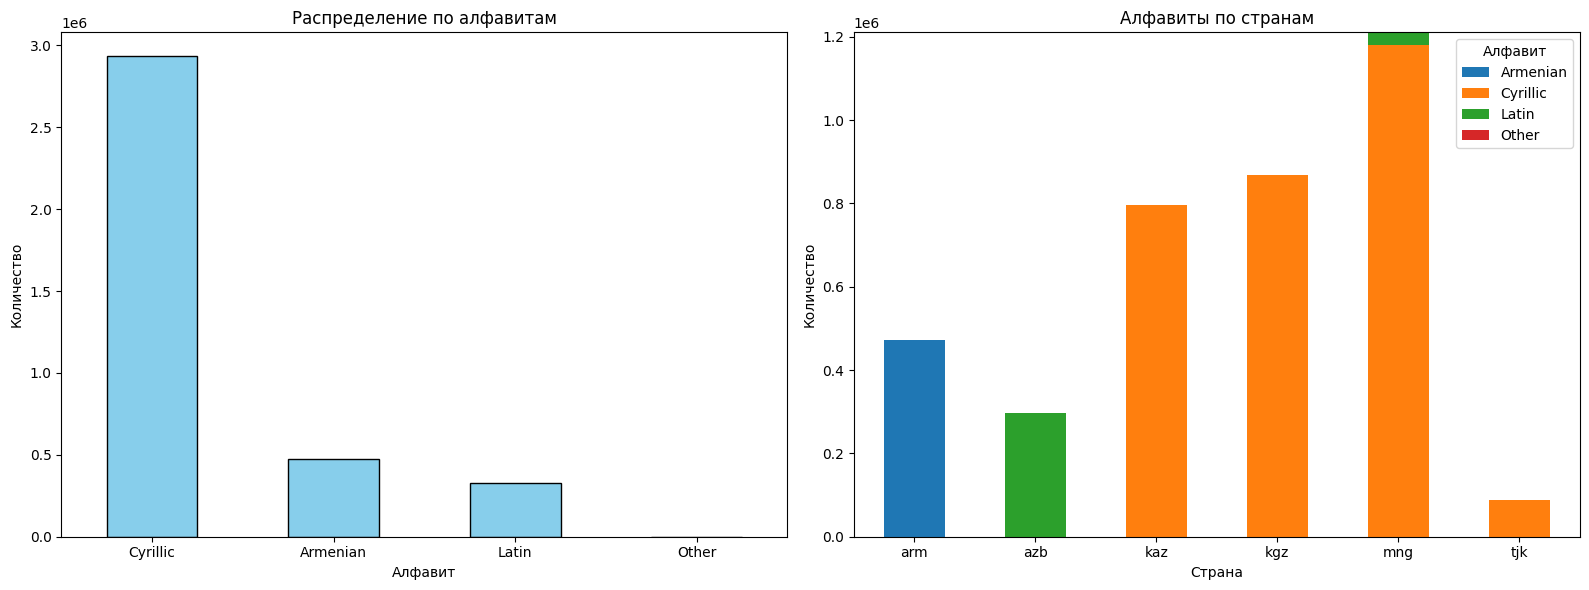

In [20]:
def detect_alphabet(text):
    if pd.isna(text):
        return None
    text = str(text)
    if any('\u0530' <= c <= '\u058F' for c in text):
        return 'Armenian'
    if any('А' <= c <= 'я' or c in 'ЁёӐӑӖӗҪҫӲӳ' for c in text):
        return 'Cyrillic'
    if any('A' <= c <= 'z' for c in text):
        return 'Latin'
    return 'Other'

df['alphabet'] = df['party_name'].apply(detect_alphabet)

alpha_data = df['alphabet'].dropna()

# Графики
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

alpha_data.value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Распределение по алфавитам')
axes[0].set_xlabel('Алфавит')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

pd.crosstab(df['country'], df['alphabet']).plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Алфавиты по странам')
axes[1].set_xlabel('Страна')
axes[1].set_ylabel('Количество')
axes[1].legend(title='Алфавит')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Вывод:** В other странные симолы (точки, тире, нули). 

Для модели:
- 3 основных алфавита: Armenian, Cyrillic, Latin
- Нужна транслитерация: Armenian → Latin, Cyrillic → Latin
- Other: можно игнорировать

### 6.3 Анализ названий компаний

Уникальных компаний: 1,182,617
Средняя длина: 33.8
Мин: 1, Макс: 533


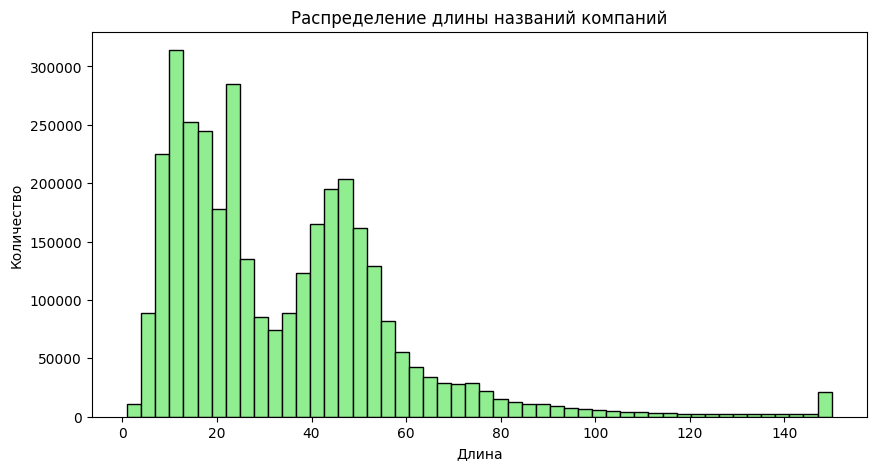


ТОП-10 КОМПАНИЙ:
company_name_norm
անհայտ կազմակերպություն                                                      123828
зэс эрдэнийн хувь                                                             22585
նեո մետալս հոլդինգ լիմիթեդ                                                    19106
абн микрофинансылык компаниясы ачык акционердик коому                          9767
նեո մետալս հոլդինգ լիմիթեդ բաժնետոմսերով սահմանափակ մասնավոր ընկերություն      8905
արդյունաբերական ընկերություն բը                                                8744
ուրբանեվենտ պլյուս սպը                                                         7078
պրոմիշլեննայա կոմպանիա                                                         5477
ամփ հոլդինգս փբը                                                               5188
коммерциялык банк кыргызстан ачык акционердик коомунун семетей филиалы         4291
Name: count, dtype: int64

ЮРИДИЧЕСКИЕ ФОРМЫ:
  ООО: 1,401
  АО: 3,248
  ЗАО: 81
  ТОО: 17,227
  ИП: 24,160
  LTD: 14,999
  

In [21]:
# Уникальные компании
print(f"Уникальных компаний: {df['company_name_norm'].nunique():,}")

# Длина названий
comp_len = df['company_name_norm'].dropna().str.len()
print(f"Средняя длина: {comp_len.mean():.1f}")
print(f"Мин: {comp_len.min()}, Макс: {comp_len.max()}")

# Гистограмма длины
plt.figure(figsize=(10, 5))
plt.hist(comp_len.clip(0, 150), bins=50, edgecolor='black', color='lightgreen')
plt.title('Распределение длины названий компаний')
plt.xlabel('Длина')
plt.ylabel('Количество')
plt.show()

# Топ-10 компаний
print("\nТОП-10 КОМПАНИЙ:")
print(df['company_name_norm'].value_counts().head(10))

# Юридические формы
forms = ['ООО', 'АО', 'ЗАО', 'ТОО', 'ИП', 'LTD', 'LLC', 'INC', 'CORP', 'L.L.C.', 'ОсОО', 'ГП', 'ЧП']
print("\nЮРИДИЧЕСКИЕ ФОРМЫ:")
for f in forms:
    count = df['company_name_norm'].str.contains(f, case=False, na=False).sum()
    if count > 0:
        print(f"  {f}: {count:,}")

**Вывод:** Юридические формы можно нормализовать: ТОО ≈ ОсОО ≈ ООО ≈ LTD ≈ LLC

### 6.4 Поиск патернов и аномалий

In [22]:
# Имена только из заглавных букв
# Убираем \u0530 из регулярки, проверяем армянский отдельно
arm_upper = df['party_name'].dropna().apply(
    lambda x: all('\u0530' <= c <= '\u058F' and c.isupper() for c in str(x))
)

# Для кириллицы и латиницы
other_upper = df['party_name'].dropna().str.match(r'^[А-ЯA-ZЁӐӖҪӲ]+$')

upper_mask = arm_upper | other_upper
print(f"Имен заглавными: {upper_mask.sum():,}")

# Имена с цифрами или спецсимволами — убрать \d
special_mask = df['party_name'].dropna().str.contains(r'[0-9@#$%^&*+=/\\[\]{}|~<>]', na=False, regex=True)
print(f"Имен с цифрами/спецсимволами: {special_mask.sum():,}")

# Короткие имена (1-2 символа)
short = df['party_name'].dropna()[df['party_name'].str.len() <= 2]
print(f"Коротких имен (1-2 символа): {len(short):,}")
print("\nПримеры коротких имен:")
print(short.value_counts().head(15))

# Одинаковые названия у разных компаний
dup_companies = df.dropna(subset=['company_name_norm', 'company_public_id'])\
                  .groupby('company_name_norm')['company_public_id'].nunique()
same_name_diff_id = dup_companies[dup_companies > 1]
print(f"\nОдинаковых названий у разных компаний: {len(same_name_diff_id):,}")
print("\nПримеры:")
print(same_name_diff_id.head(10))

Имен заглавными: 1,070
Имен с цифрами/спецсимволами: 80,472
Коротких имен (1-2 символа): 149

Примеры коротких имен:
party_name
-     14
Ли    14
Ив    12
Су     6
Лу     6
Ма     6
Ян     5
ГП     5
Лю     5
ЮП     5
Ву     4
Ай     4
48     3
Го     3
Хе     3
Name: count, dtype: int64

Одинаковых названий у разных компаний: 17,687

Примеры:
company_name_norm
01 ai kazakhstan ltd жеке компаниясы                     2
1 май шаруа қожалығы                                     2
100 kvadratov kz жауапкершілігі шектеулі серіктестігі    2
140 high school жауапкершілігі шектеулі серіктестігі     2
17 регион жауапкершілігі шектеулі серіктестігі           2
1991 жауапкершілігі шектеулі серіктестігі                2
24 7insurance                                            2
362                                                      2
3dos                                                     2
4с 1 жауапкершілігі шектеулі серіктестігі                2
Name: company_public_id, dtype: int64


Выводы: 
- заглавные → lower() при нормализации
- Одинаковые названия компаний - сложный кейс для matching: одинаковое название ≠ одна компания

### 6.5 Общий вывод

**Что нужно сделать для baseline:**

1. Нормализация текста:
   - Привести к нижнему регистру
   - Удалить спецсимволы, цифры, точки, тире
   - Убрать лишние пробелы

2. Транслитерация:

   - Armenian → Latin
   - Cyrillic → Latin
   - Latin оставить как есть

3. Юридические формы:

   - Нормализовать: ТОО ≈ ОсОО ≈ ООО ≈ LTD ≈ LLC → убрать или заменить на единый маркер
   - Удалять из названий при сравнении

4. Сложные случаи (потом):

   - Сокращения ("Ли", "ГП", "ЮП") — непонятно что значат
   - Одинаковые названия у разных компаний — нужны негативные примеры в обучении
   - Короткие имена (1-2 символа) — пока не трогаем

## 7. Анализ размеченных данных

### 7.1 Статистика размеченных данных

Записей с party_public_id: 112,141
Уникальных сущностей (ID): 53,427

Средний размер кластера: 2.10
Медианный размер: 1
Максимальный размер: 13783

Кластеров по размерам:
  Размер 1: 28,730
  Размер 2: 18,212
  Размер 3: 4,482
  Размер 4: 1,432
  Размер 5+: 571


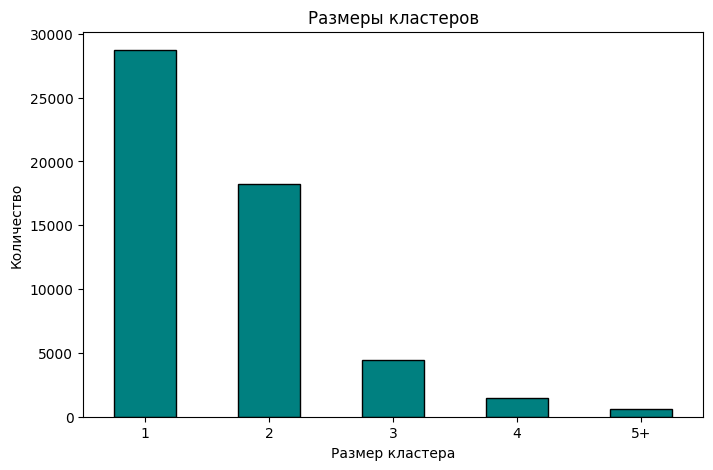

In [26]:
# Только размеченные
labeled = df[df['party_public_id'].notna()]

print(f"Записей с party_public_id: {len(labeled):,}")
print(f"Уникальных сущностей (ID): {labeled['party_public_id'].nunique():,}")

# Размеры кластеров
sizes = labeled.groupby('party_public_id').size()
print(f"\nСредний размер кластера: {sizes.mean():.2f}")
print(f"Медианный размер: {sizes.median():.0f}")
print(f"Максимальный размер: {sizes.max()}")

# Группировка для гистограммы
size_cats = sizes.apply(lambda x: '5+' if x >= 5 else str(x))
size_counts = size_cats.value_counts()
order = ['1', '2', '3', '4', '5+']
size_counts = size_counts.reindex(order)

print("\nКластеров по размерам:")
for k, v in size_counts.items():
    print(f"  Размер {k}: {v:,}")

# Гистограмма
plt.figure(figsize=(8, 5))
size_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Размеры кластеров')
plt.xlabel('Размер кластера')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

**Выводы:** 
- 54% сущностей встречаются 1 раз — не с чем сравнивать для обучения
- 34% кластеров размера 2 — основная база для создания пар (таргет = 1)
- Кластеры 3+ — 12% — хорошие примеры вариаций имен
- Гигантский кластер 13,783 — вероятно, "Неизвестная организация" или подобное

**Для создания обучающих пар:**
- Кластеры размера 1: бесполезны (не с чем создавать положительные пары)
- Кластеры размера 2: 18,212 × 1 пара = 18,212 положительных пар
- Кластеры размера 3: 4,482 × 3 пары = 13,446 пар
- Кластеры размера 4:    1,432 × 6 пар      = 8,592
- Для кластера размера 5+ будем брать 10 пар на кластер: 571 × 10 пар = 5,710

Всего: ~45,000 положительных пар

### 7.2 Анализ вариаций в кластерах

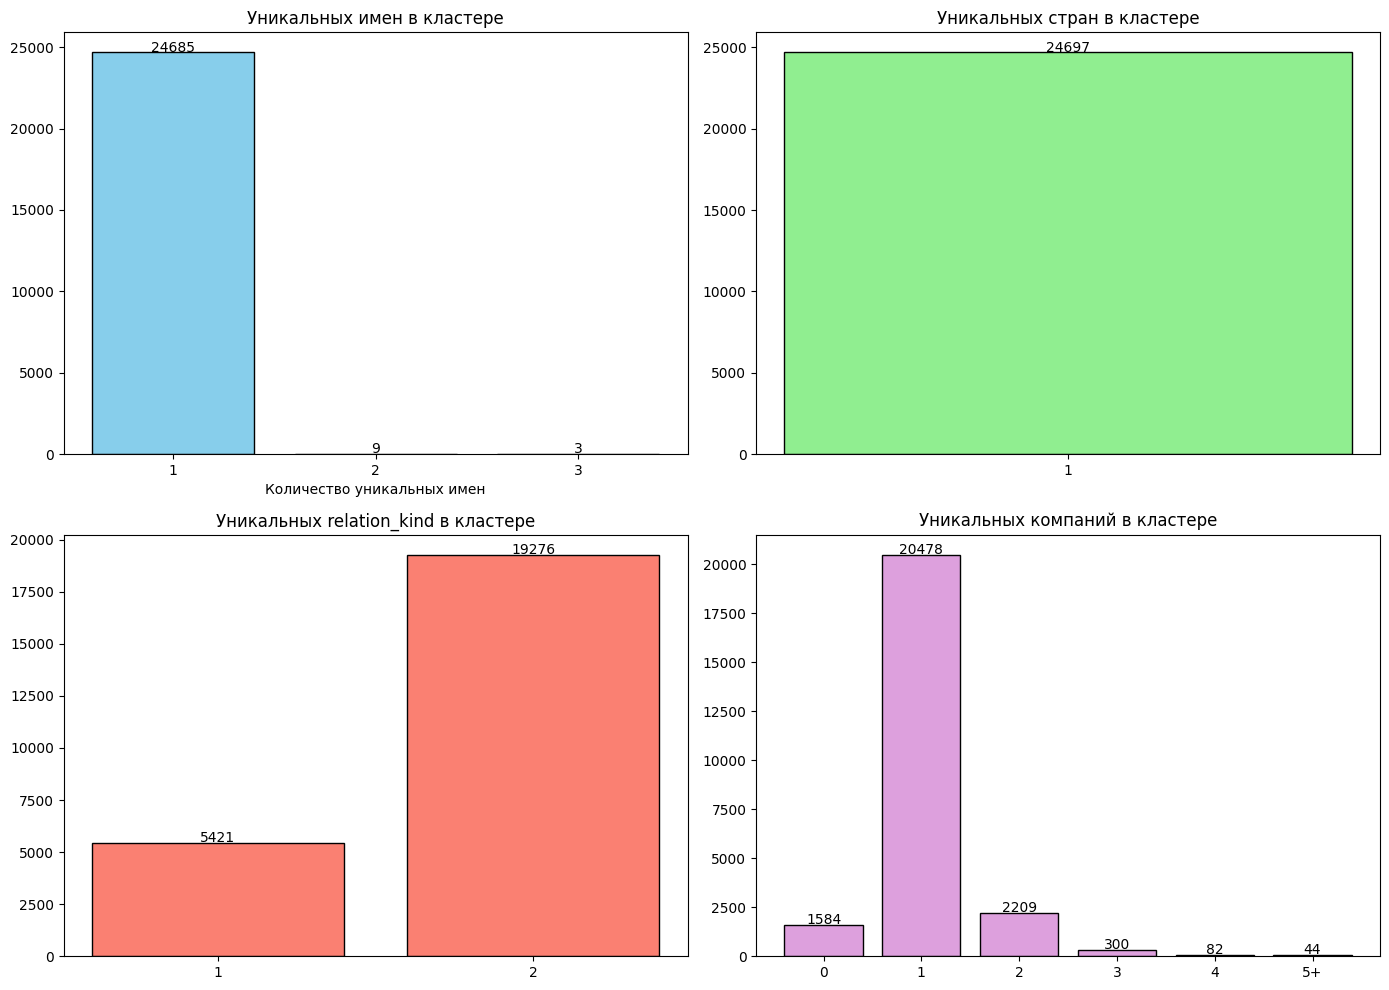

In [28]:
# Анализ вариаций внутри кластеров размера 2+
labeled = df[df['party_public_id'].notna()]
sizes = labeled.groupby('party_public_id').size()
dup_ids = sizes[sizes >= 2].index
dup_data = labeled[labeled['party_public_id'].isin(dup_ids)]

def analyze_cluster(group):
    return pd.Series({
        'unique_names': group['party_name'].nunique(),
        'unique_countries': group['country'].nunique(),
        'unique_relations': group['relation_kind'].nunique(),
        'unique_companies': group['company_name_norm'].nunique(),
    })

cluster_stats = dup_data.groupby('party_public_id').apply(analyze_cluster)

# Гистограммы с явными категориями
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Уникальные имена
name_counts = cluster_stats['unique_names'].value_counts().sort_index()
axes[0, 0].bar(name_counts.index.astype(str), name_counts.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Уникальных имен в кластере')
axes[0, 0].set_xlabel('Количество уникальных имен')
for i, v in enumerate(name_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center')

# Уникальные страны
country_counts = cluster_stats['unique_countries'].value_counts().sort_index()
axes[0, 1].bar(country_counts.index.astype(str), country_counts.values, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Уникальных стран в кластере')
for i, v in enumerate(country_counts.values):
    axes[0, 1].text(i, v + 50, str(v), ha='center')

# Уникальные relation_kind
rel_counts = cluster_stats['unique_relations'].value_counts().sort_index()
axes[1, 0].bar(rel_counts.index.astype(str), rel_counts.values, color='salmon', edgecolor='black')
axes[1, 0].set_title('Уникальных relation_kind в кластере')
for i, v in enumerate(rel_counts.values):
    axes[1, 0].text(i, v + 50, str(v), ha='center')

# Уникальные компании
comp_counts = cluster_stats['unique_companies'].value_counts().sort_index()
# Группируем 5+ через pd.concat
comp_clean = comp_counts.copy()
if len(comp_clean) > 5:
    over5 = comp_clean[5:].sum()
    comp_clean = pd.concat([comp_clean[:5], pd.Series({'5+': over5})])
axes[1, 1].bar(comp_clean.index.astype(str), comp_clean.values, color='plum', edgecolor='black')
axes[1, 1].set_title('Уникальных компаний в кластере')
for i, v in enumerate(comp_clean.values):
    axes[1, 1].text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

**Выводы:** 
1. Имена почти не варьируются. Транслитерация и опечатки почти не встречаются в разметке. Это упрощает задачу для baseline, но усложняет для ML
2. Кросс-страновых связей нет. Признак `country` будет очень сильным
3. Тип связи часто меняется. `relation_kind` — хороший контекстный признак

### 7.3 Типизация вариаций

In [29]:
# Найдем все кластеры с разными именами (их всего 12)
multi_name = cluster_stats[cluster_stats['unique_names'] > 1]
print(f"Всего кластеров с разными именами: {len(multi_name)}")

for cid in multi_name.index:
    names = dup_data[dup_data['party_public_id'] == cid]['party_name'].unique()
    print(f"\nID: {cid}")
    for n in names:
        print(f"  {n}")

Всего кластеров с разными именами: 12

ID: arm_party_08c10e0c2e663101
  ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ
  ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ
  Պրոմիշլեննայա կոմպանիա

ID: arm_party_54db7bcf8f23be5d
  «ՆԵՈ ՄԵՏԱԼՍ» ՍՊԸ
  «ՆԵՈ ՄԵՏԱԼՍ»

ID: arm_party_5c386a8f7cd9dfaf
  «ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ
  «ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»

ID: arm_party_5e037f5ac852c3bf
  ՈՒՐԲԱՆԵՎԵՆՏ ՊԼՅՈՒՍ ՍՊԸ
  Ուրբանեվենտ Պլյուս ՍՊԸ

ID: arm_party_6555697887fd6a3e
  ՄԻԿՇԻՆ
  «ՄԻԿՇԻՆ»

ID: arm_party_9e0901689ff90734
  «ԶԱՆԳԵԶՈՒՐԻ ՊՂՆՁԱՄՈԼԻԲԴԵՆԱՅԻՆ ԿՈՄԲԻՆԱՏ» ՓԲԸ
  "Զանգեզուրի պղնձամոլիբդենային կոմբինատ" ՓԲԸ
  «ԶԱՆԳԵԶՈՒՐԻ ՊՂՆՁԱՄՈԼԻԲԴԵՆԱՅԻՆ ԿՈՄԲԻՆԱՏ»

ID: arm_party_a22eeccd27959921
  «ՄՈՒՆ ՄԵԹԱԼՍ» ՓԲԸ
  «ՄՈՒՆ ՄԵԹԱԼՍ»
  ՄՈՒՆ ՄԵԹԱԼՍ

ID: arm_party_abea8f0a66567aca
  «ՄԱՍԿՕ ՄԱՅՆ»
  «ՄԱՍԿՕ ՄԱՅՆ» ՓԲԸ

ID: arm_party_ae9f9798299f0a7c
  ԱՎԻԱՏԵԽՆԱԼՈԳԻԱ ԳԱՄ ՓԲԸ
  ԱՎԻԱՏԵԽՆՈԼՈԳԻԱ  ԳԱՄ ՓԲԸ

ID: arm_party_e37a0726e4bad216
  «ՍԹԱՐ ԴԱՍԹ»
  «ՍԹԱՐ ԴԱՍԹ» ՓԲԸ

ID: arm_party_ecf2ba27d1eca9fc
  «ԱՄՓ ՀՈԼԴԻՆԳ»
  «ԱՄՓ ՀՈԼԴԻՆԳ» ՍՊԸ

ID: arm_party_f9f19c440afc7cf6
  «ՀՐ

**Вывод:** Все на армянском, в основном паттерны это регистр, кавычки, опечатки но их мало. Для модели потребуется аугментация

### 7.4 Общий вывод

1. Статистика:
   - 112,141 запись, 53,427 уникальных сущностей
   - 54% кластеров — размер 1 (бесполезны для обучения)
   - ~50,000 положительных пар можно создать
   - Гигантский кластер 13,783 — ограничим 10 парами

2. Вариативность
   - Всего 12 кластеров с разными именами из 24,697
   - Нет кросс-страновых связей, нет транслитерации
   - Основные паттерны: регистр, кавычки
   - Всё на армянском

**Что это значит:**
- Для baseline — задача простая (exact match + нормализация)
- Для ML — нужна аугментация
- `country` — сильный признак (всегда одинаковый в кластере)
- `relation_kind` — полезный контекст (меняется в 78% кластеров)

## 8. Временной анализ

### 8.1 Анализ дат

Диапазон дат: 2006-07-28 00:00:00 — 2026-03-30 00:00:00
Пропущено дат: 0


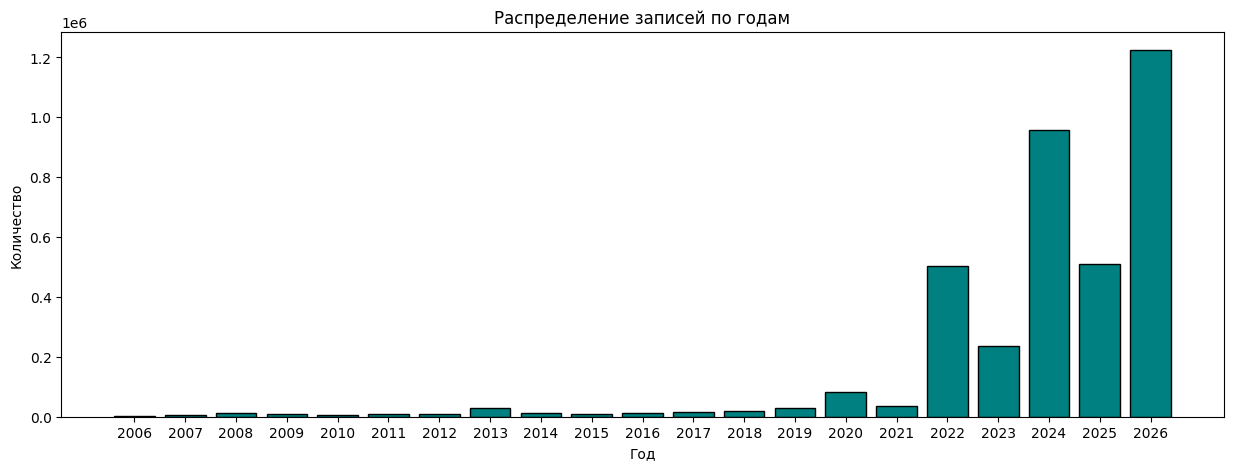

In [30]:
# Преобразуем даты
df['date'] = pd.to_datetime(df['source_snapshot_date'], errors='coerce')

# Исправляем tjk — даты в Unix timestamp
tjk_mask = (df['country'] == 'tjk') & (df['date'].isna())
tjk_dates = pd.to_datetime(df.loc[tjk_mask, 'source_snapshot_date'].astype(float), unit='s', errors='coerce')
df.loc[tjk_mask, 'date'] = tjk_dates

print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Пропущено дат: {df['date'].isna().sum():,}")

df['year'] = df['date'].dt.year
year_counts = df['year'].value_counts().sort_index()

# Гистограмма
plt.figure(figsize=(15, 5))
years_int = [int(y) for y in year_counts.index]
plt.bar(years_int, year_counts.values, color='teal', edgecolor='black')
plt.title('Распределение записей по годам')
plt.xlabel('Год')
plt.ylabel('Количество')
plt.xticks(years_int)
plt.show()

**Вывод:** Распределение неравномерное, старых мало новых много (это хорошо).

### 8.2 Связь времени и дубликатов

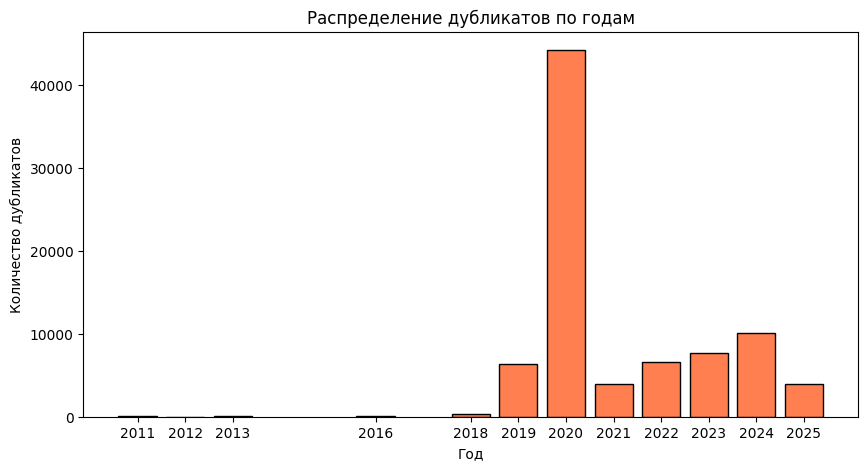


Кластеров с 2+ разными датами: 6,917 из 53,427
Средний разброс дат: 825 дней
Максимальный разброс: 4229 дней


In [32]:
# Дубликаты по годам (размеченные)
labeled = df[df['party_public_id'].notna()]

# Дубликаты внутри кластеров — записи с одинаковым ID
dup_records = labeled[labeled.duplicated('party_public_id', keep=False)]

# По годам
year_dup = dup_records['year'].value_counts().sort_index()

# Гистограмма
plt.figure(figsize=(10, 5))
years_int = [int(y) for y in year_dup.index]
plt.bar(years_int, year_dup.values, color='coral', edgecolor='black')
plt.title('Распределение дубликатов по годам')
plt.xlabel('Год')
plt.ylabel('Количество дубликатов')
plt.xticks(years_int)
plt.show()

# Одна сущность в разные даты
cluster_dates = labeled.groupby('party_public_id')['date'].agg(['min', 'max', 'nunique'])
cluster_dates['timespan_days'] = (cluster_dates['max'] - cluster_dates['min']).dt.days
multi_date = cluster_dates[cluster_dates['nunique'] > 1]

print(f"\nКластеров с 2+ разными датами: {len(multi_date):,} из {len(cluster_dates):,}")
print(f"Средний разброс дат: {multi_date['timespan_days'].mean():.0f} дней")
print(f"Максимальный разброс: {multi_date['timespan_days'].max():.0f} дней")

**Вывод:** Большинство кластеров - это записи в одну дату, тоесть снапшоты. Дата может быть признаком запись за один ень вероятнее дубликаты. 2020 год наверное массовая выгрузка. Записи с большим разбросом интересный кейс для анализа. Ниже привден этот анализ

In [33]:
# Кластеры с максимальным разбросом дат
top_span = cluster_dates[cluster_dates['nunique'] > 1].nlargest(10, 'timespan_days')

print("Топ-5 кластеров с максимальным разбросом дат:")
for cid in top_span.index:
    cluster = labeled[labeled['party_public_id'] == cid]
    names = cluster['party_name'].unique()
    dates = sorted(cluster['date'].unique())
    span = (dates[-1] - dates[0]).days
    
    print(f"\nID: {cid}")
    print(f"  Разброс: {span} дней ({span/365:.1f} лет)")
    print(f"  Записей: {len(cluster)}")
    print(f"  Имена: {names[:3]}")
    print(f"  Даты: {dates[0].date()} — {dates[-1].date()}")
    print(f"  Страна: {cluster['country'].unique()[0]}")

Топ-5 кластеров с максимальным разбросом дат:

ID: tjk_party_028414d54bf369a2
  Разброс: 4229 дней (11.6 лет)
  Записей: 4
  Имена: <ArrowStringArray>
['Алимахмадов Алишер']
Length: 1, dtype: str
  Даты: 2011-03-01 — 2022-09-28
  Страна: tjk

ID: tjk_party_9c08b79d784cd8d6
  Разброс: 4229 дней (11.6 лет)
  Записей: 7
  Имена: <ArrowStringArray>
['Абдиев Кароматулло Азизуллоевич']
Length: 1, dtype: str
  Даты: 2011-03-01 — 2022-09-28
  Страна: tjk

ID: tjk_party_a14f4e0ed97abb98
  Разброс: 4229 дней (11.6 лет)
  Записей: 4
  Имена: <ArrowStringArray>
['Шарифов Шавкат Муминович']
Length: 1, dtype: str
  Даты: 2011-03-01 — 2022-09-28
  Страна: tjk

ID: tjk_party_956eb977c9096ea2
  Разброс: 3820 дней (10.5 лет)
  Записей: 7
  Имена: <ArrowStringArray>
['Акрамов Мансур Валиевич']
Length: 1, dtype: str
  Даты: 2011-03-01 — 2021-08-15
  Страна: tjk

ID: tjk_party_032ae0a7ce928479
  Разброс: 3468 дней (9.5 лет)
  Записей: 3
  Имена: <ArrowStringArray>
['Эркая Мехмет Али']
Length: 1, dtype: str

**Выводы:** Самый большой разброс у Таджикистана, вероятно потому что только по нему есть исторические данные.

### 8.3 Общий вывод

1. Данные:
   - Диапазон: 2006–2026 (20 лет)
   - Основной объем: 2022–2026 (2.4M из 3.7M записей)
   - 2006–2021: старые данные, очень мало

2. Дубликаты и время:

   - 87% кластеров — записи за одну дату (снапшоты)
   - 13% кластеров — сущность появляется в разные даты (разброс до 11 лет)
   - Таджикистан — единственная страна с длинной историей
   - 2020 год — аномальный пик дубликатов (44 тыс.)

3. Для baseline:

   - Дата НЕ нужна как признак
   - Большой разброс дат не меняет сущность (тот же человек)
   - Можно игнорировать время для простой модели

4. Для ML:

   - Дата может помочь для различения тезок (разные люди в разное время)

## 9. Анализ числовых данных

### 9.1 Доли владения

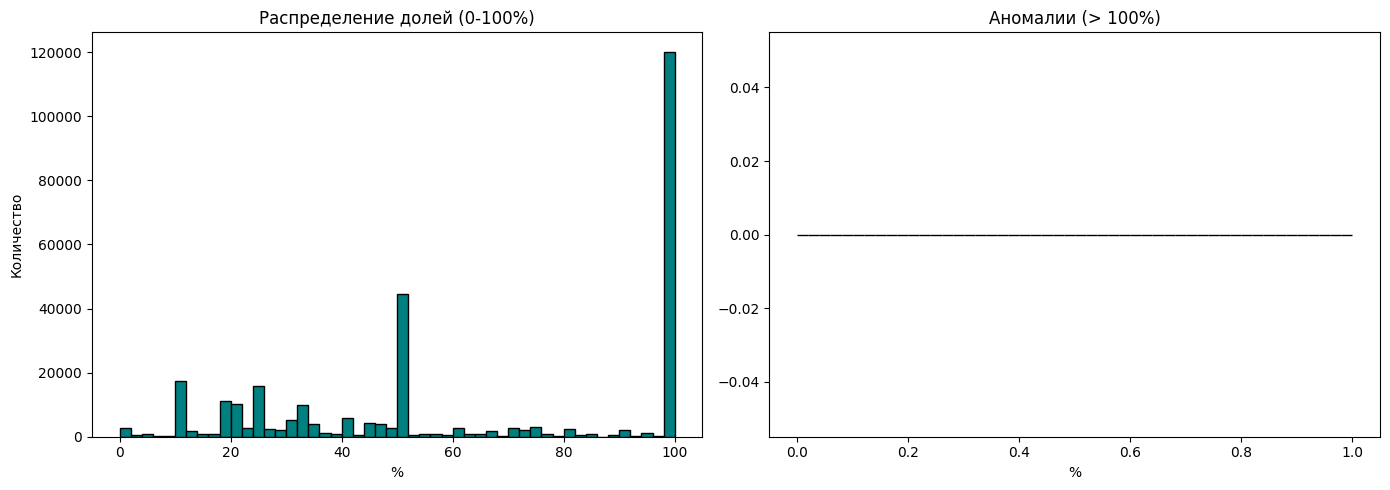


В размеченных данных: 50


In [34]:
# Доли владения
shares = df['ownership_share_pct'].dropna()

# Гистограмма
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(shares.clip(0, 100), bins=50, edgecolor='black', color='teal')
axes[0].set_title('Распределение долей (0-100%)')
axes[0].set_xlabel('%')
axes[0].set_ylabel('Количество')

axes[1].hist(shares[shares > 100], bins=50, edgecolor='black', color='coral')
axes[1].set_title('Аномалии (> 100%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

# В размеченных данных
shares_labeled = df[df['party_public_id'].notna()]['ownership_share_pct'].dropna()
print(f"\nВ размеченных данных: {len(shares_labeled):,}")

Заполнено: 298,157 из 3,733,247 (8.0%)
Среднее: 63.2
Медиана: 50.0
Мин: 0.0
Макс: 100.0


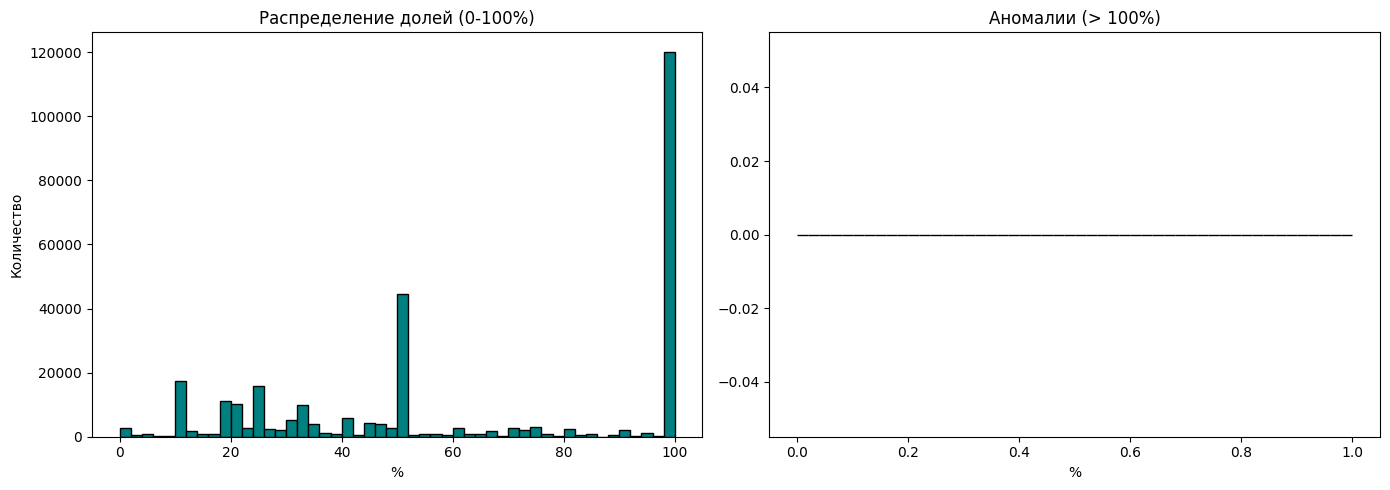


В размеченных данных: 50 (бесполезно)


In [35]:
# Доли владения
shares = df['ownership_share_pct'].dropna()

print(f"Заполнено: {len(shares):,} из {len(df):,} ({len(shares)/len(df)*100:.1f}%)")
print(f"Среднее: {shares.mean():.1f}")
print(f"Медиана: {shares.median():.1f}")
print(f"Мин: {shares.min()}")
print(f"Макс: {shares.max()}")

# Гистограмма
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(shares.clip(0, 100), bins=50, edgecolor='black', color='teal')
axes[0].set_title('Распределение долей (0-100%)')
axes[0].set_xlabel('%')
axes[0].set_ylabel('Количество')

axes[1].hist(shares[shares > 100], bins=50, edgecolor='black', color='coral')
axes[1].set_title('Аномалии (> 100%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

# В размеченных данных
shares_labeled = df[df['party_public_id'].notna()]['ownership_share_pct'].dropna()
print(f"\nВ размеченных данных: {len(shares_labeled):,} (бесполезно)")

**Вывод:** Для baseline бесполезный для ML можно будет использовать как ополнительный признак

### 9.2 Связь с другими признаками

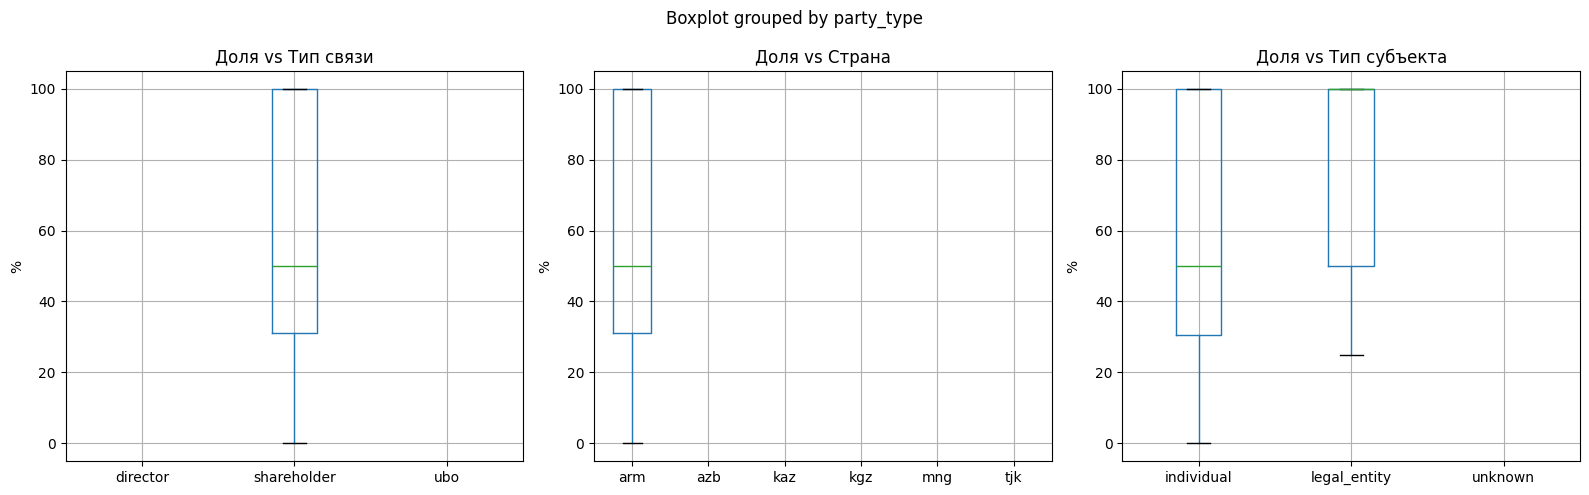

In [36]:
# Связь с другими признаками
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Доля vs relation_kind
df.boxplot(column='ownership_share_pct', by='relation_kind', ax=axes[0])
axes[0].set_title('Доля vs Тип связи')
axes[0].set_ylabel('%')
axes[0].set_xlabel('')

# Доля vs страна
df.boxplot(column='ownership_share_pct', by='country', ax=axes[1])
axes[1].set_title('Доля vs Страна')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')

# Доля vs party_type
df.boxplot(column='ownership_share_pct', by='party_type', ax=axes[2])
axes[2].set_title('Доля vs Тип субъекта')
axes[2].set_ylabel('%')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

**Вывод:** Доля есть только в тех запиясх где страна Армения и тип связи shareholder. Типа субъекта 2 individual и legal_entity

### 9.3 Общий вывод

`ownership_share_pct` для baseline игнорируем. Если и добавлять — то только на этапе ML как дополнительный признак, когда он доступен

## 10. Базовая нормализация текста

In [23]:
LEGAL_FORMS = [
    'ооо', 'зао', 'оао', 'пао',
    'llc', 'ltd', 'inc', 'corp',
    'company', 'co', 'gmbh'
]

In [24]:
def normalize_text(text):
    
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    
    # unicode normalize
    text = unicodedata.normalize('NFKD', text)
    
    # remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [25]:
def remove_legal_forms(text):
    
    tokens = text.split()
    
    tokens = [t for t in tokens if t not in LEGAL_FORMS]
    
    return " ".join(tokens)

In [26]:
def translit_to_latin(text):
    
    if pd.isna(text):
        return ""
    
    return unidecode(text)

In [27]:
df['name_norm'] = df['party_name'].apply(normalize_text)

df['name_clean'] = df['name_norm'].apply(remove_legal_forms)

df['name_latin'] = df['name_clean'].apply(translit_to_latin)

**Вывод:** Была проведена базовая нормализация текста

## 11. Анализ алфавитов и мультьтиязычности

In [28]:
def detect_script(text):
    
    if pd.isna(text):
        return 'unknown'
    
    text = str(text)
    
    has_cyrillic = bool(re.search(r'[А-Яа-яЁё]', text))
    has_latin = bool(re.search(r'[A-Za-z]', text))
    has_armenian = bool(re.search(r'[\u0530-\u058F]', text))
    has_georgian = bool(re.search(r'[\u10A0-\u10FF]', text))
    
    scripts = []
    
    if has_cyrillic:
        scripts.append('cyrillic')
        
    if has_latin:
        scripts.append('latin')
        
    if has_armenian:
        scripts.append('armenian')
        
    if has_georgian:
        scripts.append('georgian')
    
    if len(scripts) == 0:
        return 'unknown'
    
    if len(scripts) > 1:
        return 'mixed'
    
    return scripts[0]

In [29]:
df['script'] = df['party_name'].apply(detect_script)

df['script'].value_counts()

script
cyrillic    2927522
armenian     471677
latin        328376
mixed          5289
unknown         383
Name: count, dtype: int64

In [30]:
mixed_examples = df[df['script'] == 'mixed']['party_name'].head(20)

mixed_examples.tolist()

['ՆԱՐԵԳ ՍԱՀԱԿՅԱՆNAREG',
 'ՆԱՐԵԳ ՍԱՀԱԿՅԱՆNAREG',
 'Ադել Մուհամմադ Ալի Ջասիմ Ալ Մարզուqի',
 'Lիաննա Հայրապետյան',
 'Ադել Մուհամմադ Ալի Ջասիմ Ալ Մարզուqի',
 'Lիաննա Հայրապետյան',
 'Lիաննա Հայրապետյան',
 'Ադել Մուհամմադ Ալի Ջասիմ Ալ Մարզուqի',
 'Ադել Մուհամմադ Ալի Ջասիմ Ալ Մարզուqի',
 'Ռոբերտ Բոբել III',
 'Ռոբերտ Բոբել III',
 'Մխիթար Mkhitar',
 'Ռոբերտ Բոբել III',
 'Ռոբերտ Բոբել III',
 'Ադել Մուհամմադ Ալի Ջասիմ Ալ Մարզուqի',
 'ՆԱՐԵԳ ՍԱՀԱԿՅԱՆNAREG',
 'Ադել Մուհամմադ Ալի Ջասիմ Ալ Մարզուqի',
 'ՆԱՐԵԳ ՍԱՀԱԿՅԱՆNAREG',
 'ՆԱՐԵԳ ՍԱՀԱԿՅԱՆNAREG',
 'Ռոբերտ Բոբել III']

In [31]:
unknown_examples = df[df['script'] == 'unknown']['party_name'].head(20)
unknown_examples.tolist()

['. . .',
 '- - -',
 '— — —',
 '..... ...... .......',
 '-',
 '-',
 '-',
 '. . .',
 '-',
 '______',
 '______',
 '1000',
 '------- -------- --------',
 '-',
 '______',
 '-',
 '--- --- ---',
 '-',
 '- - -',
 '______']

In [32]:
df = df[df['script'] != 'unknown'].copy()

**Вывод:** Смешанные строки создают false negative примеры. Unknown надо чистить

## 12. Анализ Exact duplicates

In [33]:
exact_duplicates = (
    df.groupby('name_clean')
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

exact_duplicates.head(20)

,name_clean,count
1753155,անհայտ կազմակերպություն,50737
1756640,նեո մետալս հոլդինգ լիմիթեդ,14496
1756321,միրզաազիզ մուսախանով,11003
1757475,սվետլանա երշովա,8870
1753502,արդյունաբերական ընկերություն բը,8172
1756842,պրոմիշլեննայա կոմպանիա,5661
785809,замените на физическое лицо 1,5339
786908,замените на физическое лицо 2,5246
787493,замените на физическое лицо 3,4857
787604,замените на физическое лицо 4,4447


**Вывод:** Надо удалить замените на

## 13. Near duplicates analysis (fuzzy)

In [34]:
sample_names = (
    df['name_clean']
    .dropna()
    .drop_duplicates()
    .sample(5000, random_state=42)
    .tolist()
)

In [35]:
fuzzy_pairs = []

for i, name1 in enumerate(sample_names):
    
    for name2 in sample_names[i+1:]:
        
        score = fuzz.token_sort_ratio(name1, name2)
        
        if score >= 90 and name1 != name2:
            
            fuzzy_pairs.append({
                'name1': name1,
                'name2': name2,
                'score': score
            })

In [36]:
fuzzy_df = pd.DataFrame(fuzzy_pairs)

fuzzy_df.sort_values('score', ascending=False)

,name1,name2,score
42,пүрэв дамбии дорж,дамбии дорж пүрэв,100.000000
30,галдан билэгөрнөх,билэгөрнөх галдан,100.000000
31,мөнхбат тэрбиш,тэрбиш мөнхбат,100.000000
32,согласно списку 43 члена,согласно списку 4 члена,97.872340
11,замените на физическое лицо 1754,замените на физическое лицо 1540,96.875000
27,замените на физическое лицо 1192,замените на физическое лицо 1592,96.875000
33,замените на физическое лицо 1407,замените на физическое лицо 1540,96.875000
19,замените на физическое лицо 165,замените на физическое лицо 1592,95.238095
22,замените на физическое лицо 165,замените на физическое лицо 1555,95.238095
21,замените на физическое лицо 165,замените на физическое лицо 1895,95.238095


**Вывод:** Нашлись опечатки, перестановки слов и так далее. Иногда fuzzy score может быть высокий у разных людей. Поэтому только его использовать нельзя. Нужна ML - модель, которая будет учитывать:
- несколько признаков
- контекст
- дополнительные поля

## 14. Анализ транслитерации

In [37]:
translit_groups = (
    df.groupby('name_latin')['party_name']
      .unique()
      .reset_index()
)

In [38]:
translit_groups['variants_count'] = translit_groups['party_name'].apply(len)

translit_groups = translit_groups.sort_values(
    'variants_count',
    ascending=False
)

translit_groups.head(20)

,name_latin,party_name,variants_count
1440160,soglasno spisku,"[согласно списку, Согласно Списку, Согласно сп...",17
311,3 fiz litsa chlenov oo,"[3 Физ. Лица-членов Оо, 3 физ. лица- членов ОО...",17
1012661,ministerstvo obrazovaniia i nauki kyrgyzskoi r...,[Министерство образования и науки Кыргызской Р...,15
1218562,otkrytoe aktsionernoe obshchestvo rossii sko k...,"[Открытое акционерное общество ""Российско-Кырг...",13
1012688,ministerstvo prosveshcheniia kyrgyzskoi respub...,[Министерство просвещения Кыргызской Республик...,11
1153208,obshchestvennoe ob'edinenie oboronnaia sportiv...,"[Общественное объединение ""Оборонная спортивно...",11
1439693,soglasno po spisku,"[Согласно По Списку --- ---, Согласно По Списк...",11
1615121,uchrezhdenie ministerstvo obrazovaniia i nauki...,"[Учреждение ""Министерство образования и науки ...",10
1439903,soglasno predstavlennomu spisku,"[согласно представленному списку, Согласно Пре...",10
1448317,sporta i molodezhnoi politiki kyrgyzskoi respu...,[спорта и молодежной политики Кыргызской Респу...,9


**Вывод:** Одна сущность может иметь 10–15 вариантов написания. Поэтому очень важен хороший preprocessing.

## 15. Blocking

In [39]:
def blocking_key(text):
    
    if pd.isna(text):
        return 'unknown'
    
    text = normalize_text(text)
    
    tokens = text.split()
    
    if len(tokens) == 0:
        return 'unknown'
    
    return tokens[0][:4]

In [40]:
df['block_key'] = df['name_clean'].apply(blocking_key)

In [41]:
block_sizes = (
    df.groupby('block_key')
      .size()
      .reset_index(name='size')
)

In [42]:
total_pairs = len(df) * (len(df)-1) / 2

blocked_pairs = 0

for size in block_sizes['size']:
    
    blocked_pairs += size * (size-1) / 2

reduction_ratio = 1 - (blocked_pairs / total_pairs)

print(f"Reduction ratio: {reduction_ratio:.4f}")

Reduction ratio: 0.9983


**Вывод:** До blocking 6.7 трлн пар, после 9 млрд. Но проблема в слишком больших блоках.

## 16. TF-IDF baseline

In [43]:
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2,4)
)

X = vectorizer.fit_transform(
    df['name_clean'].fillna('')
)

In [44]:
sample_idx = 0

query_vector = X[sample_idx]

similarities = cosine_similarity(
    query_vector,
    X
).flatten()

In [45]:
top_idx = similarities.argsort()[-20:][::-1]

In [46]:
print("="*60)
print("TF-IDF BASELINE")
print("="*60)

print(f"TF-IDF matrix shape: {X.shape}")

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")

print("\nQuery example:")
print(df.iloc[sample_idx]['party_name'])

print("\nTop similar entities:")
for idx in top_idx:
    
    print(df.iloc[idx]['party_name'])
    print(similarities[idx])
    
    print("-"*40)

TF-IDF BASELINE
TF-IDF matrix shape: (3732864, 256416)
Vocabulary size: 256,416

Query example:
Անդրանիկ Աբարյան

Top similar entities:
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
----------------------------------------
Անդրանիկ Աբարյան
1.0
-------------------------------------

**Вывод:** TF-IDF смог индексировать имена и искать похожие записи, однако TF-IDF плохо понимает транслитерацию, разные языки, смысл. TF-IDF хорош как baseline, но не как финальная модель

## 17. Сложные кейсы

In [47]:
df['name_length'] = df['name_clean'].str.len()

short_names = df[df['name_length'] <= 5]

short_names[['party_name']].head(30)

,party_name
3974,«ՊՐԻՔՍ»
4004,«ԹԶՀ»
4034,«ՀՈՒՇ»
4102,«Տ-ՄԵԴ»
4209,«ԹԶՀ»
4288,«ԷՎԷ»
4907,«ՀՈՒՇ»
4930,«ՀՈՒՇ»
8753,«Տ-ՄԵԴ»
9014,«ՀԵՐԵՍ»


In [48]:
initials = df[
    df['party_name']
    .str.contains(r'\b[A-ZА-Я]\.', regex=True, na=False)
]

initials[['party_name']].head(30)

,party_name
484288,K.SƏFƏRLİ ELŞƏN ELDAR OĞLU
484289,K.SƏFƏRLİ ÜZEYİR ELDAR OĞLU
501462,ALİ.Y.A. EVVAİS .
504576,MOHAMMEDKAMAL MOHAMMED A. .
507229,SEYİDOV ELDƏNİZ M.HEYDƏR OĞLU
524417,MOHAMED NAWAF N.K. AL-THANI
534927,BERTHE ANDRE A. J. .
548555,ƏHMƏDOV ƏHMƏD ABDULLA K.
552787,LEVEQUE AXEL NICOLAS L.
553099,AL-QAYSI SHAHDAN NAJAHALDEEN A.KAREEM .


In [49]:
typo_pairs = []

for i, name1 in enumerate(sample_names[:1000]):
    for name2 in sample_names[i+1:i+200]:
        if name2 is None:
            continue
        lev = textdistance.levenshtein.normalized_similarity(name1, name2)
        if lev > 0.85 and name1 != name2:
            typo_pairs.append({
                'name1': name1,
                'name2': name2,
                'lev_sim': lev
            })

typo_df = pd.DataFrame(typo_pairs)

if len(typo_df) > 0:
    typo_df = typo_df.sort_values('lev_sim', ascending=False)
    print(f"Найдено пар: {len(typo_df)}")
    print(typo_df.head(30))
else:
    print("Пар не найдено")

Пар не найдено


**Вывод:** Есть слишком короткие имена, также есть инициалы -> token-aware matching

## 18. Embedding baseline

In [50]:
from sentence_transformers import SentenceTransformer

In [52]:
model = SentenceTransformer(
    'paraphrase-multilingual-MiniLM-L12-v2'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [53]:
sample_texts = (
    df['name_clean']
    .fillna('')
    .head(5000)
    .tolist()
)

In [54]:
embeddings = model.encode(
    sample_texts,
    show_progress_bar=True
)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [55]:
query_id = 0

scores = cosine_similarity(
    [embeddings[query_id]],
    embeddings
).flatten()

In [56]:
top_ids = scores.argsort()[-10:][::-1]

In [57]:
for idx in top_ids:
    
    print(sample_texts[idx])
    print(scores[idx])
    
    print("-"*50)

անդրանիկ աբարյան
0.9999999
--------------------------------------------------
անդրանիկ աբարյան
0.9999999
--------------------------------------------------
անդրանիկ աբարյան
0.9999999
--------------------------------------------------
անդրանիկ աբարյան
0.9999999
--------------------------------------------------
անդրանիկ աբարյան
0.9999999
--------------------------------------------------
մեթյու ռեք
0.93038666
--------------------------------------------------
մեթյու ռեք
0.93038666
--------------------------------------------------
արտակ մուրադյան
0.9291793
--------------------------------------------------
արտակ մուրադյան
0.9291793
--------------------------------------------------
արտակ մուրադյան
0.9291793
--------------------------------------------------


# Общий вывод по результатам EDA

В ходе анализа был исследован датасет для задачи дедупликации и поиска совпадений между физическими и юридическими лицами в compliance-системе. Анализ показал, что данные действительно соответствуют реальным условиям промышленной задачи Entity Resolution: большой объем, высокая неоднородность, мультиязычность, наличие большого количества дублей, шумных записей и вариативности написаний.

**1. Общая характеристика данных**

Датасет содержит более 3.6 миллионов записей из нескольких стран:

- Армения
- Азербайджан
- Казахстан
- Кыргызстан
- Монголия
- Таджикистан

Каждая строка описывает связь между компанией и связанным субъектом (директор, владелец, участник и т.д.).

В данных присутствуют:

- физические лица;
- компании;
- государственные организации;
- технические и служебные записи;
- шумовые значения.

Главная особенность датасета — отсутствие единого стандарта написания сущностей.

**2. Мультиязычность и разные алфавиты**

Анализ показал, что данные используют сразу несколько алфавитов:

- кириллица — около 78%;
- армянский алфавит — около 13%;
- латиница — около 9%;
- смешанные записи — небольшая доля.

Это означает, что система должна уметь корректно работать одновременно:

- с русским языком;
- с армянским;
- с латинскими написаниями;
- с транслитерацией.

Особенно важно, что одна и та же сущность может встречаться:

- в кириллице;
- в латинице;
- в смешанном виде.

Например:

- армянское имя + латинское окончание;
- латинская буква внутри кириллического слова;
- смешение нескольких языков в одной записи.

Такие случаи делают невозможным использование только exact matching.

**3. Очень высокий уровень дубликатов**

После нормализации имен было обнаружено большое количество повторяющихся записей.

Примерно:

- 70% записей участвуют в duplicate-группах;
- многие сущности встречаются сотни и тысячи раз.

Были найдены крупные кластеры:

- государственные организации;
- банки;
- типовые компании;
- популярные имена физических лиц.

Это говорит о том, что задача дедупликации действительно критически важна для качества системы.

Без объединения дублей:

- информация о сущности будет фрагментирована;
- поиск будет выдавать неполные результаты;
- compliance-проверки будут ухудшаться.
  
**4. Основной источник дублей — не только опечатки**

Анализ показал, что большинство дублей возникают не из-за случайных ошибок ввода, а из-за:

- разных форм записи;
- разной пунктуации;
- наличия или отсутствия юридической формы;
- различий в регистре;
- различий в пробелах;
- транслитерации;
- изменения порядка слов;
- различий между источниками данных.

Таким образом, важнейшую роль играет качественная нормализация текста.

**5. Транслитерация является одной из ключевых проблем**

Анализ транслитерации показал большое количество групп, где одна и та же сущность имеет множество вариантов написания.

Были обнаружены:

- разные варианты перевода кириллицы в латиницу;
- разные способы записи армянских имен;
- различия между официальной и неофициальной транслитерацией;
- смешение нескольких языков.

Это означает, что система должна учитывать не только буквальное совпадение строк, но и фонетическую близость имен.

**6. Простое fuzzy matching недостаточно**

Анализ похожих строк показал важную проблему.

Алгоритмы нечеткого сравнения действительно находят:

- перестановки слов;
- небольшие опечатки;
- близкие варианты имен.

Однако одновременно они начинают ошибочно считать похожими разные сущности.

Например:

- разные люди с одинаковыми фамилиями;
- разные компании с похожими названиями;
- разные организации с типовыми юридическими формами.

Это означает, что использование только одного текстового similarity score приведет к большому количеству ложных совпадений.

Следовательно, финальная система должна учитывать не только текст, но и дополнительные признаки:

- страну;
- тип связи;
- роль;
- контекст;
- длину имени;
- структуру записи.

**7. В данных присутствует значительный шум**

EDA выявил большое количество шумовых и малоинформативных записей:

- "согласно списку";
- "неизвестная организация";
- технические значения;
- сокращения;
- слишком короткие названия;
- записи с инициалами;
- неполные имена.

Также обнаружены:

- очень короткие сущности;
- аббревиатуры;
- записи длиной 2–5 символов.

Подобные записи особенно опасны для Entity Resolution, потому что:

- они создают огромное количество ложных совпадений;
- fuzzy matching начинает давать много ошибок;
- кластеризация становится нестабильной.

Поэтому потребуется отдельная обработка hard cases.

**8. Blocking является критически важной частью задачи**

Размер датасета делает невозможным попарное сравнение всех записей. Полное число возможных сравнений - более 6.6 триллионов пар. Даже при очень быстрых алгоритмах это вычислительно нереализуемо. После применения blocking число сравнений сократилось более чем на 99.8%. Это подтверждает, что blocking — центральная часть всей системы. При этом текущий baseline blocking уже показал хороший reduction ratio, но распределение размеров блоков оказалось крайне неравномерным многие блоки очень маленькие, некоторые содержат десятки тысяч записей.

Это означает, что потребуется:

- multi-pass blocking;
-  несколько blocking keys;
-  дополнительные стратегии ограничения размеров блоков.
  
**9. В датасете присутствует частичная разметка**

Очень важным результатом анализа стало обнаружение полей:

- party_public_id
- company_public_id

Несмотря на большое количество пропусков, эти поля позволяют автоматически получить часть размеченных данных. Если две записи имеют одинаковый party_public_id, то они с высокой вероятностью относятся к одной сущности.

Это позволяет:

- автоматически формировать positive pairs;
- обучать supervised-модель;
- строить более качественный matcher без ручной разметки.

Таким образом, задача переходит из полностью unsupervised-подхода в semi-supervised/supervised подход. Это значительно повышает потенциальное качество финальной системы.

**10. TF-IDF и embeddings показали перспективность**

Первичные baseline-эксперименты с:

- TF-IDF;
- multilingual embeddings

подтвердили, что:

- текстовые представления способны находить близкие сущности;
- особенно хорошо работают символьные n-граммы;
- embeddings потенциально помогут при кросс-языковом поиске.

Однако embeddings сами по себе не решают задачу дедупликации и должны использоваться:

- совместно с blocking;
- совместно с ML matcher;
- совместно с дополнительными признаками.

**На основании EDA была сформирована следующая стратегия построения системы.**

**Этап 1. Нормализация данных**

Создание единого preprocessing pipeline:

- очистка текста;
- удаление юридических форм;
- унификация регистра;
- транслитерация;
- сортировка токенов;
- обработка шумовых записей.

**Этап 2. Blocking**

Построение масштабируемой системы candidate generation:

- несколько blocking keys;
- multi-pass blocking;
- ограничение размеров блоков.

**Этап 3. Построение признаков**

Создание признаков для сравнения записей:

- fuzzy similarity;
- token similarity;
- embedding similarity;
- признаки по стране;
- признаки по ролям;
- длина имени;
- совпадение алфавита;
- признаки транслитерации.

**Этап 4. Формирование обучающей выборки**

Использование:

- party_public_id;
- company_public_id;

для автоматического формирования positive pairs и hard negatives.

**Этап 5. Обучение ML matcher**

Обучение модели классификации дублей:

- CatBoost;
- LightGBM.

**Этап 6. Кластеризация**

Построение графа сущностей и объединение дублей через connected components.

**Этап 7. Поисковая система**

Реализация поиска:

- retrieval через TF-IDF/embeddings;
- reranking через ML matcher.

**Этап 8. API и Docker*

Разработка REST API:

- /search
- /check_duplicate
- /deduplicate_batch

и упаковка решения в Docker-контейнер.